<a href="https://colab.research.google.com/github/muajnstu/Natural-Language-Processing-NLP-/blob/main/Fatality_analysis_in_plane_crashes_followed_by_a_data_balancing_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Pipeline Overview**
1. Install & Import
2. All Function Definitions
3. Data Loading & Preprocessing
4. TF-IDF Vectorisation + LSA
5. KMeans Clustering per Sentiment Class
6. Re-clustering (Synthetic-Minimising Strategy)
7. Cluster Filtering & Label Assignment
8. Applying SMOTE
9. Train / Test Split & Scaling
10. Classic ML — Train
11. Deep Learning — Train (LSTM / GRU / CNN / BiLSTM)
12. Transformer — Train (BERT / RoBERTa / DistilBERT / ALBERT)
13. Results — Compare & Summarise

**Install Dependencies**

In [ ]:
!pip install -q imbalanced-learn xgboost lightgbm transformers torch

**Imports**

In [ ]:
import warnings, time, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from collections import Counter
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    silhouette_score
)
from sklearn.linear_model import LogisticRegression, RidgeClassifier, Perceptron, SGDClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier,
    BaggingClassifier, ExtraTreesClassifier
)
from sklearn.svm import SVC, LinearSVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.utils.class_weight import compute_class_weight

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Conv1D, GlobalMaxPooling1D, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

print('All imports successful.')

All imports successful.


**Global Constants**

In [ ]:
# ── Reproducibility
RANDOM_STATE   = 42

# ── TF-IDF / LSA
TFIDF_MAX_FEAT = 1000
LSA_COMPONENTS = 100

# ── KMeans / clustering
KMEANS_INIT    = 10
MIN_CLUSTER_RATIO = 0.40     # drop clusters below 40% of median size
ABS_MIN_CLUSTER   = 50       # absolute floor for any cluster

# ── Train / test split
TEST_SIZE      = 0.20
VAL_SIZE       = 0.10

# ── Deep Learning
MAX_WORDS      = 20_000      # Tokenizer vocabulary size
MAX_LEN        = 100         # Padded sequence length
EMBED_DIM      = 64          # Embedding dimension
DL_EPOCHS      = 5
DL_BATCH_SIZE  = 32

# ── Transformer
TRANSFORMER_MAX_LEN   = 128
TRANSFORMER_EPOCHS    = 3
TRANSFORMER_BATCH     = 8
TRANSFORMER_LR        = 2e-5

# ── Label map
LABEL_MAP      = {0: 'positive', 1: 'negative', 2: 'neutral'}

# ── classifiers that require scaled input
NEEDS_SCALE = {
    'LogisticRegression', 'RidgeClassifier', 'SGDClassifier', 'Perceptron',
    'GaussianNB', 'BernoulliNB', 'KNeighborsClassifier',
    'LinearDiscriminantAnalysis', 'QuadraticDiscriminantAnalysis',
    'LinearSVC', 'SVC_RBF', 'MLPClassifier',
}

**All Function Definitions**
> Every helper used downstream is defined here. Run this cell once before executing any later section.

In [ ]:
# TEXT PREPROCESSING

_stop_words = set(stopwords.words('english'))
_lemmatizer = WordNetLemmatizer()

def clean_text(text: str) -> str:
    """Lowercase → strip non-alpha → remove stopwords → lemmatise."""
    text   = str(text).lower()
    text   = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [_lemmatizer.lemmatize(w) for w in tokens if w not in _stop_words]
    return ' '.join(tokens)

# CLUSTERING HELPERS

def synthetic_count(counts) -> int:
    m = max(counts)
    return sum(m - c for c in counts)


def plot_elbow_silhouette(X: np.ndarray, title: str) -> int:
    wcss, sil_scores, k_range = [], [], range(2, 11)
    for k in k_range:
        km     = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=KMEANS_INIT)
        labels = km.fit_predict(X)
        wcss.append(km.inertia_)
        sil_scores.append(silhouette_score(X, labels, sample_size=min(2000, len(X))))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(k_range, wcss, marker='o')
    ax1.set_title(f'{title} — WCSS (Elbow)'); ax1.set_xlabel('k'); ax1.set_ylabel('WCSS')
    ax2.plot(k_range, sil_scores, marker='s', color='darkorange')
    ax2.set_title(f'{title} — Silhouette'); ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette')
    plt.tight_layout(); plt.show()
    best_k = list(k_range)[sil_scores.index(max(sil_scores))]
    print(f'  Best k by silhouette: {best_k} (score={max(sil_scores):.3f})')
    return best_k


def split_large_clusters(X: np.ndarray, labels: np.ndarray,
                          min_cluster_size: int = ABS_MIN_CLUSTER) -> np.ndarray:
    new_labels = np.array(labels, dtype=object)
    for iteration in range(1, 50):
        unique, counts = np.unique(new_labels, return_counts=True)
        order          = np.argsort(-counts)
        unique, counts = unique[order], counts[order]
        if len(unique) < 2 or counts[0] <= counts[1]:
            break
        largest_name, largest_size, second_size = unique[0], counts[0], counts[1]
        k_min = math.ceil(largest_size / second_size)
        k_max = k_min + 2
        idx   = np.where(new_labels == largest_name)[0]
        X_sub = X[idx]
        print(f'Iter {iteration}: splitting "{largest_name}" '
              f'(n={largest_size}) into k={k_min}…{k_max} (second={second_size})')
        best_k, best_score, best_sublabels = None, -np.inf, None
        for k in range(k_min, k_max + 1):
            if k >= len(idx): break
            km         = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=KMEANS_INIT)
            sub_lbl    = km.fit_predict(X_sub)
            sub_counts = np.bincount(sub_lbl)
            if sub_counts.min() < min_cluster_size:
                print(f'  k={k} rejected: smallest={sub_counts.min()} < {min_cluster_size}')
                continue
            sil = silhouette_score(X_sub, sub_lbl, sample_size=min(2000, len(X_sub)))
            print(f'  k={k}: sizes={sorted(sub_counts, reverse=True)}, sil={sil:.3f}')
            if sil > best_score:
                best_score, best_k, best_sublabels = sil, k, sub_lbl
        if best_k is None:
            print(f'  No valid split for "{largest_name}" — stopping.'); break
        for i, sub in zip(idx, best_sublabels):
            new_labels[i] = f'{largest_name}_{sub}'
        new_counts = np.bincount(best_sublabels)
        print(f'  => k={best_k} (sil={best_score:.3f}), sizes={sorted(new_counts, reverse=True)}')
        print(f'  => Synthetic count: {synthetic_count(np.unique(new_labels, return_counts=True)[1]):,}\n')
    return new_labels


# TRAIN / VAL / TEST SPLIT & SCALING

def split_and_scale(X: np.ndarray, y: np.ndarray,
                    test_size: float = TEST_SIZE, val_size: float = VAL_SIZE):
    """Stratified 80/10/10 split + StandardScaler. Returns raw + scaled splits."""
    X_tv, X_test, y_tv, y_test = train_test_split(
        X, y, test_size=test_size, random_state=RANDOM_STATE, stratify=y)
    val_frac = val_size / (1.0 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_tv, y_tv, test_size=val_frac, random_state=RANDOM_STATE, stratify=y_tv)
    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_val_sc   = scaler.transform(X_val)
    X_test_sc  = scaler.transform(X_test)
    print(f'Train : {X_train_sc.shape} | {Counter(y_train)}')
    print(f'Val   : {X_val_sc.shape}   | {Counter(y_val)}')
    print(f'Test  : {X_test_sc.shape}  | {Counter(y_test)}')
    return (X_train, X_val, X_test,
            X_train_sc, X_val_sc, X_test_sc,
            y_train, y_val, y_test, scaler)


# METRICS

def calculate_metrics(y_true, y_pred, y_proba, model_name: str) -> dict:
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    if y_proba is not None:
        try:
            auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
        except ValueError:
            auc = float('nan')
    else:
        auc = float('nan')
    return {'Model': model_name, 'Accuracy': round(acc,4), 'Precision': round(prec,4),
            'Recall': round(rec,4), 'F1': round(f1,4), 'AUC': round(auc,4)}

# CLASSIC ML

def build_classifiers() -> dict:
    """Fresh dict of unfitted classifiers. No class_weight — SMOTE handles balance."""
    return {
        'LogisticRegression'           : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        'RidgeClassifier'              : RidgeClassifier(),
        'SGDClassifier'                : SGDClassifier(max_iter=1000, random_state=RANDOM_STATE),
        'Perceptron'                   : Perceptron(max_iter=1000, random_state=RANDOM_STATE),
        'GaussianNB'                   : GaussianNB(),
        'BernoulliNB'                  : BernoulliNB(),
        'KNeighborsClassifier'         : KNeighborsClassifier(n_neighbors=5),
        'LinearDiscriminantAnalysis'   : LinearDiscriminantAnalysis(),
        'QuadraticDiscriminantAnalysis': QuadraticDiscriminantAnalysis(reg_param=0.1),
        'DecisionTreeClassifier'       : DecisionTreeClassifier(random_state=RANDOM_STATE),
        'RandomForestClassifier'       : RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
        'ExtraTreesClassifier'         : ExtraTreesClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
        'AdaBoostClassifier'           : AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE),
        'GradientBoostingClassifier'   : GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
        'BaggingClassifier'            : BaggingClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
        'LinearSVC'                    : LinearSVC(max_iter=2000, random_state=RANDOM_STATE),
        'SVC_RBF'                      : SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
        'XGBClassifier'                : XGBClassifier(n_estimators=200, random_state=RANDOM_STATE, eval_metric='mlogloss', verbosity=0),
        'LGBMClassifier'               : LGBMClassifier(n_estimators=200, random_state=RANDOM_STATE, verbosity=-1),
        'MLPClassifier'                : MLPClassifier(hidden_layer_sizes=(256,128), max_iter=300, random_state=RANDOM_STATE),
    }


def run_classic_ml(X_train, X_test, X_train_sc, X_test_sc, y_train, y_test) -> dict:
    classifiers = build_classifiers()
    results     = {}
    print(f'{"Model":<36}  {"Acc":>6}  {"F1":>6}  {"AUC":>6}  {"Time":>6}')
    print('-' * 65)
    for name, clf in classifiers.items():
        Xtr = X_train_sc if name in NEEDS_SCALE else X_train
        Xte = X_test_sc  if name in NEEDS_SCALE else X_test
        t0  = time.time()
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            clf.fit(Xtr, y_train)
            y_pred = clf.predict(Xte)
        elapsed = time.time() - t0
        y_proba = None
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            if hasattr(clf, 'predict_proba'):
                y_proba = clf.predict_proba(Xte)
            elif hasattr(clf, 'decision_function'):
                df_scores = clf.decision_function(Xte)
                e = np.exp(df_scores - df_scores.max(axis=1, keepdims=True))
                y_proba = e / e.sum(axis=1, keepdims=True)
        m = calculate_metrics(y_test, y_pred, y_proba, name)
        m['Time(s)'] = round(elapsed, 2)
        results[name] = m
        print(f'{name:<36}  {m["Accuracy"]:>6.4f}  {m["F1"]:>6.4f}  {m["AUC"]:>6.4f}  {elapsed:>5.1f}s')
    return results

# DEEP LEARNING  (Keras)

def prepare_dl_data(X_train_raw, X_val_raw, X_test_raw,
                    y_train, y_val, y_test):
    tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
    tokenizer.fit_on_texts(X_train_raw)
    def _seq(X): return pad_sequences(tokenizer.texts_to_sequences(X), maxlen=MAX_LEN)
    X_train_seq = _seq(X_train_raw)
    X_val_seq   = _seq(X_val_raw)
    X_test_seq  = _seq(X_test_raw)
    if hasattr(y_train, 'values'): y_train = y_train.values
    if hasattr(y_val,   'values'): y_val   = y_val.values
    if hasattr(y_test,  'values'): y_test  = y_test.values
    print(f'DL sequences — train:{X_train_seq.shape}  val:{X_val_seq.shape}  test:{X_test_seq.shape}')
    return X_train_seq, X_val_seq, X_test_seq, y_train, y_val, y_test, tokenizer


def create_lstm():   return Sequential([Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN), LSTM(128), Dense(3, activation='softmax')])
def create_gru():    return Sequential([Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN), GRU(128), Dense(3, activation='softmax')])
def create_cnn():    return Sequential([Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN), Conv1D(128,5,activation='relu'), GlobalMaxPooling1D(), Dense(3, activation='softmax')])
def create_bilstm(): return Sequential([Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN), Bidirectional(LSTM(128)), Dense(3, activation='softmax')])


def train_dl_model(name, model_fn,
                   X_train_seq, y_train, X_val_seq, y_val,
                   X_test_seq, y_test, class_weight_dict) -> dict:
    """Train one Keras model with class_weight to handle original imbalance."""
    print(f'\nTraining {name}...')
    model = model_fn()
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    model.fit(X_train_seq, y_train,
              epochs=DL_EPOCHS, batch_size=DL_BATCH_SIZE,
              validation_data=(X_val_seq, y_val),
              class_weight=class_weight_dict,   # ← handles imbalance natively
              verbose=1)
    y_proba = model.predict(X_test_seq, verbose=0)
    y_pred  = np.argmax(y_proba, axis=1)
    return calculate_metrics(y_test, y_pred, y_proba, name)


def run_dl_models(X_train_seq, y_train_dl, X_val_seq, y_val_dl,
                  X_test_seq, y_test_dl, class_weight_dict) -> dict:
    dl_results = {}
    for name, fn in [('LSTM', create_lstm), ('GRU', create_gru),
                     ('CNN', create_cnn), ('BiLSTM', create_bilstm)]:
        dl_results[name] = train_dl_model(name, fn,
                                          X_train_seq, y_train_dl,
                                          X_val_seq,   y_val_dl,
                                          X_test_seq,  y_test_dl,
                                          class_weight_dict)
    return dl_results


# TRANSFORMER  (PyTorch / HuggingFace)

class WeightedLossTrainer(Trainer):
    """Trainer subclass that applies class weights to the cross-entropy loss."""
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights   # torch.Tensor on correct device

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        logits  = outputs.logits
        device  = logits.device
        weights = self.class_weights.to(device) if self.class_weights is not None else None
        loss    = torch.nn.functional.cross_entropy(logits, labels, weight=weights)
        return (loss, outputs) if return_outputs else loss


class TorchTextDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        if hasattr(labels, 'values'): labels = labels.values
        self.labels    = torch.tensor(labels, dtype=torch.long)
        self.encodings = encodings
    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item
    def __len__(self): return len(self.labels)


def _tokenize_for_transformer(tokenizer, X, max_length=TRANSFORMER_MAX_LEN):
    return tokenizer(list(X), add_special_tokens=True, max_length=max_length,
                     padding='max_length', truncation=True,
                     return_attention_mask=True, return_tensors='pt')


def train_pytorch_transformer(model_name, checkpoint, num_labels,
                               X_train, y_train, X_val, y_val, X_test, y_test,
                               class_weight_tensor,
                               max_length=TRANSFORMER_MAX_LEN) -> dict:
    print(f'\n{"="*70}\nTRAINING {model_name}\n{"="*70}')
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    model     = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=num_labels)
    model.config.problem_type = 'single_label_classification'

    train_ds = TorchTextDataset(_tokenize_for_transformer(tokenizer, X_train, max_length), y_train)
    val_ds   = TorchTextDataset(_tokenize_for_transformer(tokenizer, X_val,   max_length), y_val)
    test_ds  = TorchTextDataset(_tokenize_for_transformer(tokenizer, X_test,  max_length), y_test)

    training_args = TrainingArguments(
        output_dir=f'./results_{model_name.lower()}',
        num_train_epochs=TRANSFORMER_EPOCHS,
        per_device_train_batch_size=TRANSFORMER_BATCH,
        per_device_eval_batch_size=TRANSFORMER_BATCH,
        learning_rate=TRANSFORMER_LR, warmup_ratio=0.1,
        eval_strategy='epoch', save_strategy='no',
        logging_strategy='epoch', max_grad_norm=1.0, report_to='none'
    )
    trainer = WeightedLossTrainer(          # ← weighted loss handles imbalance
        model=model, args=training_args,
        train_dataset=train_ds, eval_dataset=val_ds,
        class_weights=class_weight_tensor
    )
    trainer.train()

    test_outputs = trainer.predict(test_ds)
    logits  = test_outputs.predictions
    y_pred  = np.argmax(logits, axis=1)
    probs   = torch.nn.functional.softmax(torch.tensor(logits), dim=1)
    y_proba = torch.nan_to_num(probs).cpu().numpy()
    y_true  = y_test.values if hasattr(y_test, 'values') else y_test
    return calculate_metrics(y_true, y_pred, y_proba, model_name)


def run_transformer_models(X_train, y_train, X_val, y_val, X_test, y_test,
                            num_labels, class_weight_tensor) -> dict:
    checkpoints = {
        'BERT'      : 'bert-base-uncased',
        'RoBERTa'   : 'roberta-base',
        'DistilBERT': 'distilbert-base-uncased',
        'ALBERT'    : 'albert-base-v2',
    }
    results = {}
    for name, ckpt in checkpoints.items():
        results[name] = train_pytorch_transformer(
            name, ckpt, num_labels,
            X_train, y_train, X_val, y_val, X_test, y_test,
            class_weight_tensor)
    return results

# REPORTING

def build_results_df(all_results: dict) -> pd.DataFrame:
    df = pd.DataFrame.from_dict(all_results, orient='index')
    df.index.name = 'Model'
    return df.drop(columns=['Model'], errors='ignore').sort_values('AUC', ascending=False)


def plot_model_comparison(results_df, metric='F1', top_n=15):
    top = results_df.sort_values(metric, ascending=False).head(top_n)
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(top.index[::-1], top[metric][::-1], color='steelblue')
    ax.set_xlabel(metric)
    ax.set_title(f'Top-{top_n} Models — {metric}')
    ax.set_xlim(0, 1)
    for bar, val in zip(bars, top[metric][::-1]):
        ax.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)
    plt.tight_layout(); plt.show()


def plot_confusion_matrix(y_true, y_pred, model_name,
                           class_names=('positive','negative','neutral')):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix — {model_name}')
    plt.tight_layout(); plt.show()


print('All functions defined.')


All functions defined.


**Data Loading & Preprocessing**

In [ ]:
url = 'https://raw.githubusercontent.com/sanjidarifa114-source/plane-crash-/refs/heads/main/new_sentiment.csv'
df  = pd.read_csv(url)
print(df.head())
print('\nSentiment distribution:')
print(df['target'].value_counts())

                                       Circumstances    target
0  The single engine airplane departed Dayton-McC...  negative
1  Assembled at Cricklewood Airfield in May 1918,...  positive
2  The single engine aircraft was completing a lo...  negative
3  Lt. Frank Stuart Patterson, son and nephew of ...  negative
4  The aircraft crashed iupon landing somewhere i...   neutral

Sentiment distribution:
target
negative    12076
positive    11538
neutral      4922
Name: count, dtype: int64


In [ ]:
df_cleaned = df.copy()

# Drop duplicates
before = df_cleaned.shape
df_cleaned = df_cleaned.drop_duplicates()
print(f'Duplicates removed: {before[0] - df_cleaned.shape[0]} rows')
print(f'Shape: {before} → {df_cleaned.shape}')

# Clean text
df_cleaned['Circumstances'] = df_cleaned['Circumstances'].apply(clean_text)
print('\nSample cleaned reviews:')
print(df_cleaned['Circumstances'].head())

Duplicates removed: 831 rows
Shape: (28536, 2) → (27705, 2)

Sample cleaned reviews:
0    single engine airplane departed daytonmccook f...
1    assembled cricklewood airfield may aircraft de...
2    single engine aircraft completing local traini...
3    lt frank stuart patterson son nephew cofounder...
4    aircraft crashed iupon landing somewhere franc...
Name: Circumstances, dtype: object


**TF-IDF Vectorisation + LSA (Dimensionality Reduction)**

In [ ]:
tfidf = TfidfVectorizer(max_features=TFIDF_MAX_FEAT, stop_words=list(_stop_words))
X_vectorized = tfidf.fit_transform(df_cleaned['Circumstances'])
print('TF-IDF shape:', X_vectorized.shape)

svd = TruncatedSVD(n_components=LSA_COMPONENTS, random_state=RANDOM_STATE)
X_reduced = svd.fit_transform(X_vectorized)
explained = svd.explained_variance_ratio_.sum()
print(f'LSA: {LSA_COMPONENTS} components explain {explained:.1%} of variance')
print('Reduced shape:', X_reduced.shape)

TF-IDF shape: (27705, 1000)
LSA: 100 components explain 49.3% of variance
Reduced shape: (27705, 100)


**Clustering per Sentiment Class**

In [ ]:
y_labels = df_cleaned['target'].values

X_pos = X_reduced[y_labels == 'positive']
X_neg = X_reduced[y_labels == 'negative']
X_neu = X_reduced[y_labels == 'neutral']

print('positive:', X_pos.shape)
print('negative:', X_neg.shape)
print('neutral   :', X_neu.shape)

positive: (11385, 100)
negative: (12012, 100)
neutral   : (4308, 100)


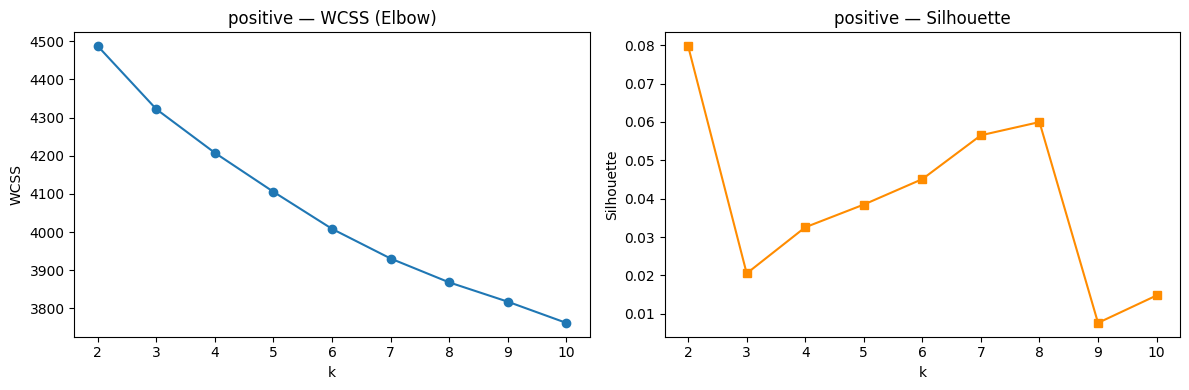

  Best k by silhouette: 2 (score=0.080)


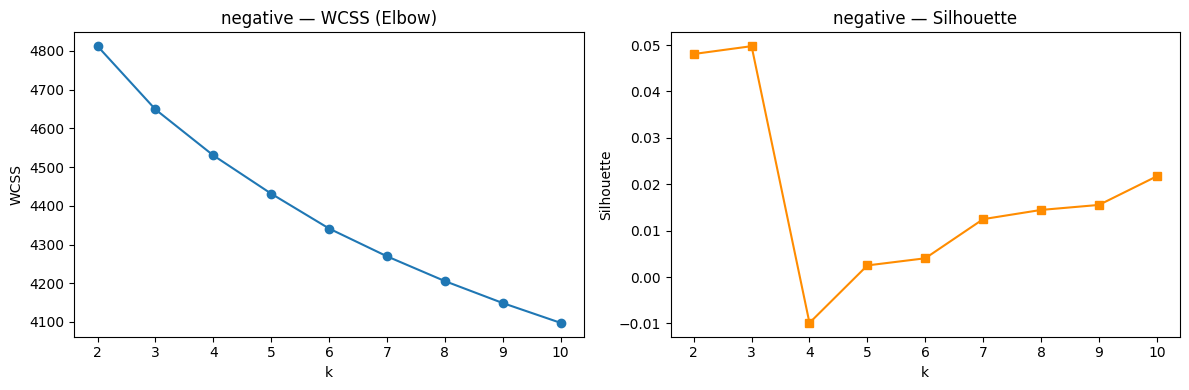

  Best k by silhouette: 3 (score=0.050)


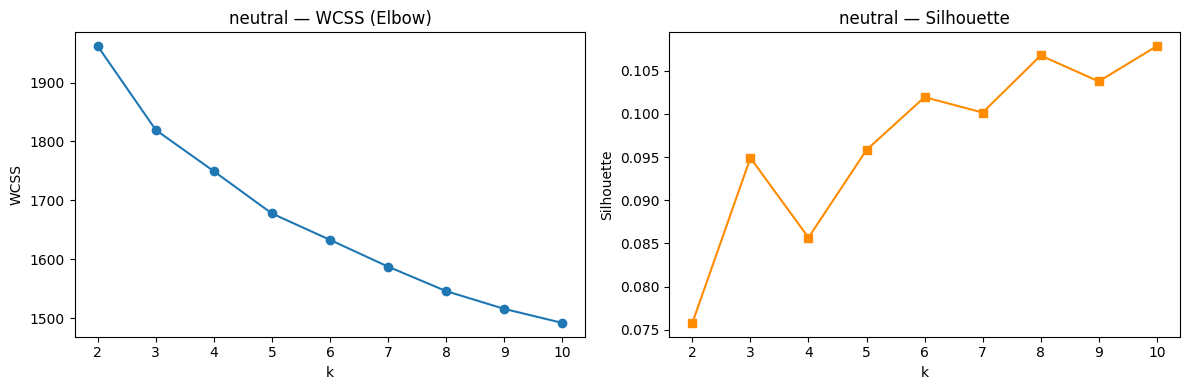

  Best k by silhouette: 10 (score=0.108)


In [ ]:
# Elbow + silhouette — inspect plots before proceeding
best_k_pos = plot_elbow_silhouette(X_pos, 'positive')
best_k_neg = plot_elbow_silhouette(X_neg, 'negative')
best_k_neu = plot_elbow_silhouette(X_neu, 'neutral')

In [ ]:
# Override any k here if the plots suggest a different choice
n_clusters_positive = best_k_pos
n_clusters_negative = best_k_neg
n_clusters_neutral  = best_k_neu

km_pos = KMeans(n_clusters=n_clusters_positive, random_state=RANDOM_STATE, n_init=KMEANS_INIT)
km_neg = KMeans(n_clusters=n_clusters_negative, random_state=RANDOM_STATE, n_init=KMEANS_INIT)
km_neu = KMeans(n_clusters=n_clusters_neutral,  random_state=RANDOM_STATE, n_init=KMEANS_INIT)

labels_pos = km_pos.fit_predict(X_pos)
labels_neg = km_neg.fit_predict(X_neg)
labels_neu = km_neu.fit_predict(X_neu)

print('Cluster distribution:')
print('  positive:', np.bincount(labels_pos))
print('  negative:', np.bincount(labels_neg))
print('  neutral   :', np.bincount(labels_neu))

Cluster distribution:
  positive: [3766 7619]
  negative: [1268 7928 2816]
  neutral   : [203 920 594 283 225 150 796 259 485 393]


**Cluster + Re-clustering**

In [ ]:
df_pos = pd.DataFrame(X_pos); df_pos['target'] = 'positive'; df_pos['Cluster_Label'] = ['positive_' + str(i+1) for i in labels_pos]
df_neg = pd.DataFrame(X_neg); df_neg['target'] = 'negative'; df_neg['Cluster_Label'] = ['negative_' + str(i+1) for i in labels_neg]
df_neu = pd.DataFrame(X_neu); df_neu['target'] = 'neutral';    df_neu['Cluster_Label'] = ['neutral_'    + str(i+1) for i in labels_neu]

final_df = pd.concat([df_pos, df_neg, df_neu], ignore_index=True)
print('Cluster distribution (initial):')
print(final_df['Cluster_Label'].value_counts())
print(f'\nInitial synthetic count estimate: {synthetic_count(final_df["Cluster_Label"].value_counts().values):,}')

Cluster distribution (initial):
Cluster_Label
negative_2    7928
positive_2    7619
positive_1    3766
negative_3    2816
negative_1    1268
neutral_2      920
neutral_7      796
neutral_3      594
neutral_9      485
neutral_10     393
neutral_4      283
neutral_8      259
neutral_5      225
neutral_1      203
neutral_6      150
Name: count, dtype: int64

Initial synthetic count estimate: 91,215


In [ ]:
X_features   = final_df.drop(columns=['target', 'Cluster_Label']).values
labels_array = final_df['Cluster_Label'].to_numpy()

new_labels = split_large_clusters(X_features, labels_array, min_cluster_size=ABS_MIN_CLUSTER)

counts_after = pd.Series(new_labels).value_counts()
print('\nAfter re-clustering:')
print(counts_after)
print(f'\nFinal synthetic count estimate: {synthetic_count(counts_after.values):,}')
print(f'Max cluster: {counts_after.max()}, Min cluster: {counts_after.min()}')

Iter 1: splitting "negative_2" (n=7928) into k=2…4 (second=7619)
  k=2: sizes=[np.int64(5987), np.int64(1941)], sil=-0.001
  k=3: sizes=[np.int64(4556), np.int64(1765), np.int64(1607)], sil=-0.005
  k=4: sizes=[np.int64(2563), np.int64(2319), np.int64(1722), np.int64(1324)], sil=0.004
  => k=4 (sil=0.004), sizes=[np.int64(2563), np.int64(2319), np.int64(1722), np.int64(1324)]
  => Synthetic count: 109,437

Iter 2: splitting "positive_2" (n=7619) into k=3…5 (second=3766)
  k=3: sizes=[np.int64(3650), np.int64(2994), np.int64(975)], sil=0.060
  k=4: sizes=[np.int64(3234), np.int64(2988), np.int64(963), np.int64(434)], sil=0.065
  k=5: sizes=[np.int64(2954), np.int64(2277), np.int64(1023), np.int64(931), np.int64(434)], sil=0.070
  => k=5 (sil=0.070), sizes=[np.int64(2954), np.int64(2277), np.int64(1023), np.int64(931), np.int64(434)]
  => Synthetic count: 55,147

Iter 3: splitting "positive_1" (n=3766) into k=2…4 (second=2954)
  k=2: sizes=[np.int64(2009), np.int64(1757)], sil=0.067
  k=

**Filtering & Label Assignment**

In [ ]:
cluster_counts  = pd.Series(new_labels).value_counts()
median_size     = cluster_counts.median()
MIN_CLUSTER_SIZE = max(ABS_MIN_CLUSTER, int(MIN_CLUSTER_RATIO * median_size))

print(f'Median cluster size : {median_size:.0f}')
print(f'Filter threshold    : {MIN_CLUSTER_SIZE}')

small_clusters = cluster_counts[cluster_counts < MIN_CLUSTER_SIZE].index.tolist()
print(f'Clusters to drop ({len(small_clusters)}):', small_clusters)

df_recluster = final_df.copy()
df_recluster['Cluster_Label'] = new_labels
filtered_df  = df_recluster[~df_recluster['Cluster_Label'].isin(small_clusters)].copy()

print('\nShape after filtering:', filtered_df.shape)
print('\nRemaining cluster sizes:')
print(filtered_df['Cluster_Label'].value_counts())

In [ ]:
def _sentiment_sort_key(label):
    order = {'positive': 0, 'negative': 1, 'neutral': 2}
    prefix = label.split('_')[0]
    return (order.get(prefix, 99), label)

sorted_labels = sorted(filtered_df['Cluster_Label'].unique(), key=_sentiment_sort_key)
cluster_label_to_serial = {lbl: f'label_{i}' for i, lbl in enumerate(sorted_labels)}

filtered_df['Serial_Cluster_Label'] = (
    filtered_df['Cluster_Label']
    .map(cluster_label_to_serial)
    .apply(lambda x: int(x.split('_')[1]))
)
filtered_df = filtered_df.drop(columns=['Cluster_Label'])

print('Serial cluster distribution:')
print(filtered_df['Serial_Cluster_Label'].value_counts().sort_index())

**Balancing**

In [ ]:
original_indices = filtered_df.index.values
filtered_df      = filtered_df.reset_index(drop=True)

X_smote_input = filtered_df.drop(columns=['target', 'Serial_Cluster_Label']).values
y_smote_input = filtered_df['Serial_Cluster_Label'].values

print('Class distribution BEFORE SMOTE:')
for k, v in sorted(Counter(y_smote_input).items()):
    print(f'  label_{k}: {v}')

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=3)
X_balanced, y_balanced_clusters = smote.fit_resample(X_smote_input, y_smote_input)

print(f'\nAfter SMOTE: {X_balanced.shape[0]:,} total samples '
      f'({X_balanced.shape[0] - len(X_smote_input):,} synthetic added)')
print('Class distribution AFTER SMOTE:')
for k, v in sorted(Counter(y_balanced_clusters).items()):
    print(f'  label_{k}: {v}')

In [ ]:
# Map fine-grained cluster labels back to 3-class sentiment
serial_to_cluster = {int(v.split('_')[1]): k for k, v in cluster_label_to_serial.items()}

def _cluster_to_sentiment(serial_int: int) -> int:
    cluster_str = serial_to_cluster[serial_int]
    if cluster_str.startswith('positive'): return 0
    if cluster_str.startswith('negative'): return 1
    return 2

y_balanced = np.array([_cluster_to_sentiment(c) for c in y_balanced_clusters])

print('Final 3-class distribution after SMOTE:')
for k, v in sorted(Counter(y_balanced).items()):
    print(f'  {LABEL_MAP[k]}: {v:,}')

Final 3-class distribution after SMOTE:
  positive: 19,721
  negative: 20,254
  neutral: 7,462


**Train / Validation / Test Split & Scaling**

ML

In [ ]:
(
    X_train, X_val, X_test,
    X_train_sc, X_val_sc, X_test_sc,
    y_train, y_val, y_test,
    scaler
) = split_and_scale(X_balanced, y_balanced)

print(f'\nClassic ML is training on {X_train.shape[0]:,} SMOTE-balanced samples.')


Train : (33205, 100) | Counter({np.int64(1): 14177, np.int64(0): 13805, np.int64(2): 5223})
Val   : (4744, 100)   | Counter({np.int64(1): 2026, np.int64(0): 1972, np.int64(2): 746})
Test  : (9488, 100)  | Counter({np.int64(1): 4051, np.int64(0): 3944, np.int64(2): 1493})

Classic ML is training on 33,205 SMOTE-balanced samples.


DL & Transformer

In [ ]:
le_orig = LabelEncoder()
y_orig  = le_orig.fit_transform(df_cleaned['Circumstances'].values)
# Ensure order matches LABEL_MAP
label_order = ['positive', 'negative', 'neutral']
y_orig = np.array([label_order.index(s) for s in df_cleaned['target'].values])

text_orig = df_cleaned['Circumstances'].values

print('Original class distribution:')
for k, v in sorted(Counter(y_orig).items()):
    print(f'  {LABEL_MAP[k]}: {v}')

# split on original data
text_tv, text_test_orig, y_tv_orig, y_test_orig = train_test_split(
    text_orig, y_orig,
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_orig
)
val_frac = VAL_SIZE / (1.0 - TEST_SIZE)
text_train_orig, text_val_orig, y_train_orig, y_val_orig = train_test_split(
    text_tv, y_tv_orig,
    test_size=val_frac, random_state=RANDOM_STATE, stratify=y_tv_orig
)

print(f'\nOriginal data splits:')
print(f'  Train : {len(text_train_orig):,} | {Counter(y_train_orig)}')
print(f'  Val   : {len(text_val_orig):,}   | {Counter(y_val_orig)}')
print(f'  Test  : {len(text_test_orig):,}  | {Counter(y_test_orig)}')

# Compute class weights from training labels
cw_values = compute_class_weight('balanced', classes=np.unique(y_train_orig), y=y_train_orig)
class_weight_dict   = dict(enumerate(cw_values))
class_weight_tensor = torch.tensor(cw_values, dtype=torch.float32)

print(f'\nClass weights: {class_weight_dict}')


Original class distribution:
  positive: 11385
  negative: 12012
  neutral: 4308

Original data splits:
  Train : 19,393 | Counter({np.int64(1): 8409, np.int64(0): 7969, np.int64(2): 3015})
  Val   : 2,771   | Counter({np.int64(1): 1201, np.int64(0): 1139, np.int64(2): 431})
  Test  : 5,541  | Counter({np.int64(1): 2402, np.int64(0): 2277, np.int64(2): 862})

Class weights: {0: np.float64(0.8111850085748944), 1: np.float64(0.7687398422325287), 2: np.float64(2.144057490326147)}


**Classic ML — Train All Classifiers**

In [ ]:
classic_ml_results = run_classic_ml(
    X_train, X_test,
    X_train_sc, X_test_sc,
    y_train, y_test
)


Model                                    Acc      F1     AUC    Time
-----------------------------------------------------------------
LogisticRegression                    0.8938  0.8938  0.9743    3.4s
RidgeClassifier                       0.8550  0.8558  0.9586    0.1s
SGDClassifier                         0.8899  0.8898  0.9718    1.4s
Perceptron                            0.8645  0.8644  0.9519    0.4s
GaussianNB                            0.7807  0.7809  0.9132    0.1s
BernoulliNB                           0.7761  0.7763  0.9086    0.1s
KNeighborsClassifier                  0.8515  0.8517  0.9467    3.0s
LinearDiscriminantAnalysis            0.8607  0.8615  0.9637    0.5s
QuadraticDiscriminantAnalysis         0.8096  0.8087  0.9317    1.4s
DecisionTreeClassifier                0.8494  0.8495  0.8910   12.7s
RandomForestClassifier                0.9203  0.9205  0.9865  111.2s
ExtraTreesClassifier                  0.9312  0.9313  0.9895   14.6s
AdaBoostClassifier                   

**Deep Learning — LSTM / GRU / CNN / BiLSTM**



In [ ]:
print('Preparing Deep Learning sequences (original text)...')

X_train_dl, X_val_dl, X_test_dl, \
y_train_dl, y_val_dl, y_test_dl, \
dl_tokenizer = prepare_dl_data(
    text_train_orig, text_val_orig, text_test_orig,
    y_train_orig,    y_val_orig,    y_test_orig
)

print('\n DL data ready!')
print(f'   Train : {X_train_dl.shape}')
print(f'   Val   : {X_val_dl.shape}')
print(f'   Test  : {X_test_dl.shape}')


Preparing Deep Learning sequences (original text)...
DL sequences — train:(19393, 100)  val:(2771, 100)  test:(5541, 100)

 DL data ready!
   Train : (19393, 100)
   Val   : (2771, 100)
   Test  : (5541, 100)


In [ ]:
dl_results = run_dl_models(
    X_train_dl, y_train_dl,
    X_val_dl,   y_val_dl,
    X_test_dl,  y_test_dl,
    class_weight_dict
)



Training LSTM...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


607/607 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.8811 - loss: 0.2778 - val_accuracy: 0.9610 - val_loss: 0.1392
Epoch 2/5
607/607 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9708 - loss: 0.0886 - val_accuracy: 0.9722 - val_loss: 0.1104
Epoch 3/5
607/607 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.9841 - loss: 0.0598 - val_accuracy: 0.9776 - val_loss: 0.1037
Epoch 4/5
607/607 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.9916 - loss: 0.0269 - val_accuracy: 0.9747 - val_loss: 0.0970
Epoch 5/5
607/607 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.9935 - loss: 0.0219 - val_accuracy: 0.9747 - val_loss: 0.0974

Training GRU...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


607/607 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.8956 - loss: 0.2591 - val_accuracy: 0.9783 - val_loss: 0.0881
Epoch 2/5
607/607 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.9837 - loss: 0.0574 - val_accuracy: 0.9812 - val_loss: 0.0756
Epoch 3/5
607/607 ━━━━━━━━━━━━━━━━━━━━ 22s 21ms/step - accuracy: 0.9926 - loss: 0.0284 - val_accuracy: 0.9805 - val_loss: 0.0873
Epoch 4/5
607/607 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9939 - loss: 0.0212 - val_accuracy: 0.9830 - val_loss: 0.0773
Epoch 5/5
607/607 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9964 - loss: 0.0171 - val_accuracy: 0.9812 - val_loss: 0.0838

Training CNN...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


607/607 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9336 - loss: 0.1763 - val_accuracy: 0.9827 - val_loss: 0.0603
Epoch 2/5
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9909 - loss: 0.0289 - val_accuracy: 0.9859 - val_loss: 0.0494
Epoch 3/5
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9974 - loss: 0.0093 - val_accuracy: 0.9848 - val_loss: 0.0461
Epoch 4/5
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9995 - loss: 0.0020 - val_accuracy: 0.9859 - val_loss: 0.0507
Epoch 5/5
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 1.0000 - loss: 4.5494e-04 - val_accuracy: 0.9874 - val_loss: 0.0541

Training BiLSTM...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


607/607 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.8785 - loss: 0.2926 - val_accuracy: 0.9350 - val_loss: 0.2032
Epoch 2/5
607/607 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9509 - loss: 0.1366 - val_accuracy: 0.9419 - val_loss: 0.1681
Epoch 3/5
607/607 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9730 - loss: 0.0847 - val_accuracy: 0.9650 - val_loss: 0.1321
Epoch 4/5
607/607 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9794 - loss: 0.0687 - val_accuracy: 0.9715 - val_loss: 0.1159
Epoch 5/5
607/607 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9828 - loss: 0.0553 - val_accuracy: 0.9697 - val_loss: 0.1077


**Transformer Fine-tuning — BERT / RoBERTa / DistilBERT / ALBERT**

> ⚠️ Requires GPU. Enable in Colab: *Runtime → Change runtime type → T4 GPU*

In [ ]:
num_classes = len(np.unique(y_orig))
print(f'Number of classes : {num_classes}')
print(f'Class weight tensor: {class_weight_tensor}')

transformer_results = run_transformer_models(
    text_train_orig, y_train_orig,
    text_val_orig,   y_val_orig,
    text_test_orig,  y_test_orig,
    num_labels=num_classes,
    class_weight_tensor=class_weight_tensor
)


**Results — Compare All Models**

In [ ]:
all_results = {
    #**classic_ml_results,
    **dl_results,
    **transformer_results
}

results_df = build_results_df(all_results)
print('\n--- Full Model Performance Summary ---\n')
print(results_df.round(4).to_string())


--- Full Model Performance Summary ---

            Accuracy  Precision  Recall      F1     AUC
Model                                                  
CNN           0.9886     0.9887  0.9886  0.9886  0.9988
ALBERT        0.9735     0.9743  0.9735  0.9735  0.9984
DistilBERT    0.9742     0.9748  0.9742  0.9742  0.9981
BERT          0.9735     0.9737  0.9735  0.9735  0.9980
GRU           0.9829     0.9829  0.9829  0.9829  0.9978
LSTM          0.9811     0.9813  0.9811  0.9811  0.9975
RoBERTa       0.9691     0.9697  0.9691  0.9692  0.9975
BiLSTM        0.9765     0.9767  0.9765  0.9765  0.9955


In [ ]:
top3_df = results_df.head(3)
print('\n--- Top 3 Models (by AUC) ---\n')
print(top3_df.round(4))

top3_names = top3_df.index.tolist()
print('\nTop 3:', top3_names)


--- Top 3 Models (by AUC) ---

            Accuracy  Precision  Recall      F1     AUC
Model                                                  
CNN           0.9886     0.9887  0.9886  0.9886  0.9988
ALBERT        0.9735     0.9743  0.9735  0.9735  0.9984
DistilBERT    0.9742     0.9748  0.9742  0.9742  0.9981

Top 3: ['CNN', 'ALBERT', 'DistilBERT']
